
#**LAB 3 (31st  January and 1st Feb 2025)**
#TOPICS COVERED : Logistic Regression

[link text](https://)# There are 2 graded questions.

Datasets: https://drive.google.com/drive/folders/14FHq7_1sK0ZjJCtXruk1fGu5il7-ubMO?usp=sharing

In [1]:
import numpy as np
import pandas as pd
import h5py
from matplotlib import pyplot as plt

%matplotlib inline

# Logistic Regression

Consider the scenario where we have a classification problem where the dependent variable is categorical in nature and the independent variables are continuous in nature. Some examples are categorizing transactions as valid or fraudulent, tumors as malignant or benign, emails as spam or not spam. All these problems can be answered with a simple **Yes** or **No**, which is why they are called **binary classification problems**.

### Why not use Linear Regression?

Consider a scenario where we need to classify whether an email is spam or not. If we use linear regression for this problem, there is a need for setting up a threshold based on which classification can be done. Say if the actual class is malignant, predicted continuous value 0.4 and the threshold value is 0.5, the data point will be classified as not malignant which can lead to serious consequences.

Linear regression is unbounded, and this brings logistic regression into the picture.

To deal with outliers, logistic regression uses the sigmoid function.

The sigmoid function is defined as:
$$\sigma(z) = \frac{e^z}{e^z+1} = \frac{1}{1+e^{-z}}$$

Plotting it looks as follows:

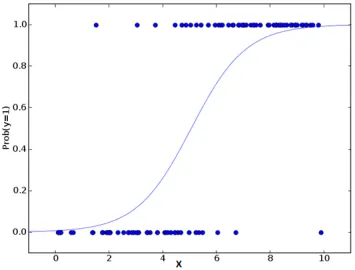

As we know from the previous class, $z$ or $h$ is our hypothesis, defined as:
$$ h=\theta_0+\theta_1X$$



# Cost Function

As we have to categorize the data into either 0 or 1, we use a new cost function which maximizes cost when data is wrongly classified and minimizes cost when data is classified properly. To achieve this functionality, we use the following function:
$$J=\frac{1}{m}\sum_{i=1}^m[-y_i\log(a_i)-(1-y_i)\log(1-a_i)]$$
Where,
$$a_i = \sigma(h_i)$$
and $y_i$ is the ground truth categorical value for element $i$.

Taking the derivative of this function with respect to $\theta_0$ and $\theta_1$, we get:
$$\frac{\partial J}{\partial \theta_1} = \frac{1}{m}(A-Y)^T\cdot X$$

$$\frac{\partial J}{\partial \theta_0}=\frac{1}{m}\sum_{i=1}^{m}(a_i-y_i)$$

Where $X,A,Y$ are the vectorized versions of $x_i,a_i,y_i$ respectively.
$\frac{1}{m}$ is used to normalize across $m$ training samples.

$\log(a_i)\to 0$ when $a_i \to 1$ and $\log(1 - a_i)\to 0$ when $(a_i) \to 0$

The function L is used in the expression for the cost function J. This function L is called Binary Cross Entropy Loss Function, and the graph of the function is as displayed below. The value on the

$$L=[-y_i\log(a_i)-(1-y_i)\log(1-a_i)]$$

# Data

We will use the cats vs non-cats dataset from last class.

In [3]:
def load_dataset():
    with h5py.File('/content/drive/My Drive/DL_LAB/LAB3/train_catvnoncat.h5', "r") as train_dataset:
        train_set_x_orig = np.array(train_dataset["train_set_x"][:])
        train_set_y_orig = np.array(train_dataset["train_set_y"][:])

    with h5py.File('/content/drive/My Drive/DL_LAB/LAB3/test_catvnoncat.h5', "r") as test_dataset:
        test_set_x_orig = np.array(test_dataset["test_set_x"][:])
        test_set_y_orig = np.array(test_dataset["test_set_y"][:])
        classes = np.array(test_dataset["list_classes"][:])

    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
train_x, train_y, test_x, test_y, classes = load_dataset()

In [6]:
train_x.shape

(209, 64, 64, 3)

# Preprocessing

We preprocess the code by flattening the image to a shape of (num_pixels_x * num_pixels_y * 3, 1), and scale all pixel values to become values between 0 and 1.

In [7]:
def preprocess(x):
    x = x.reshape(x.shape[0], -1).T
    x = x / 255
    return x

In [8]:
train_x = preprocess(train_x)
test_x = preprocess(test_x)

In [9]:
train_x.shape

(12288, 209)

# Helper Functions

## Sigmoid

We implement the sigmoid function or $\sigma (z) = \frac{1}{1 + e^{-z}}$

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

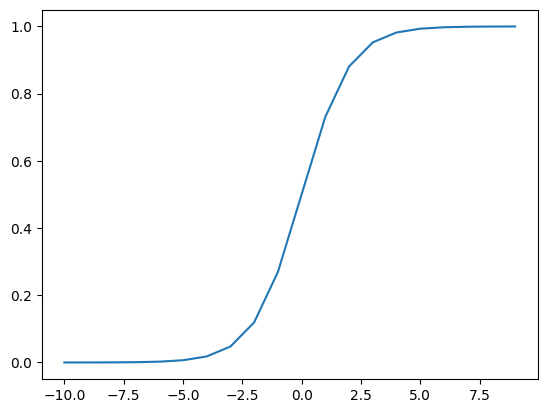

In [11]:
plt.plot([i for i in range(-10,10)], [sigmoid(i) for i in range(-10,10)])

We implement a function to initialize values of $\theta_0$ and $\theta_1$ as $b$ or bias and $w$ or weight. We initialize $w$ to be an array of zeros of size (num_pixels_x * num_pixels_y * 3, 1) and $b$ is initialized to 0.0

In [12]:
def initialize_with_zeros(dim):
    w = np.zeros((dim, 1))
    b = 0.
    return w, b

Now we will compute cost and gradients in a function as per the following equations$$J=\frac{1}{m}\sum_{i=1}^m[-y_i\log(a_i)-(1-y_i)\log(1-a_i)]$$
$$\frac{\partial J}{\partial w} = \frac{1}{m}(A-Y)^T\cdot X$$

$$\frac{\partial J}{\partial b}=\frac{1}{m}\sum_{i=1}^{m}(a_i-y_i)$$

In [14]:
def propagate(w, b, X, Y):
    m = X.shape[1]
    A = sigmoid(np.dot(w.T, X) + b)
    cost = -1 / m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    dw = 1 / m * np.dot(X, (A - Y).T)
    db = 1 / m * np.sum(A - Y)
    cost = np.squeeze(cost)
    grads = {"dw": dw, "db": db}
    return grads, cost

Now we will optimize the parameters $w$ and $b$ using the following equations:
$$w = w - \alpha \frac{\partial J}{\partial w}$$
$$b = b - \alpha \frac{\partial J}{\partial b}$$

We will also give an option to print the cost once every 100 epochs or iterations

In [15]:
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost=False):
    costs = []
    for i in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        dw = grads["dw"]
        db = grads["db"]
        w = w - learning_rate * dw
        b = b - learning_rate * db
        if i % 100 == 0:
            costs.append(cost)
        if print_cost and i % 100 == 0:
            print("Cost after iteration %i: %f" % (i, cost))
    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}
    return params, grads, costs

Now we will implement the prediction function, essentially defined as $$a = \sigma(wX + b)$$
We will also convert the continuous values between 0 and 1 to discrete values, 0 and 1. We determine this via a customizable threshold, currently at 0.5. Anything above this threshold is considered true or 1 else 0

In [16]:
def predict(w, b, X):
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)
    A = sigmoid(np.dot(w.T, X) + b)
    for i in range(A.shape[1]):
        if A[0, i] > 0.5:
            Y_prediction[0, i] = 1
        else:
            Y_prediction[0, i] = 0
    return Y_prediction

$$(1-\frac{\sum_{i=0}^n |y^p_i-y_i|}{n})*100$$

We will now define the model, within which we will perform all steps outlined above and train our model

In [17]:
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    w, b = initialize_with_zeros(X_train.shape[0])
    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)
    w = parameters["w"]
    b = parameters["b"]
    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)
    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test,
         "Y_prediction_train": Y_prediction_train,
         "w": w,
         "b": b,
         "learning_rate": learning_rate,
         "num_iterations": num_iterations}
    return d

In [18]:
d = model(train_x, train_y, test_x, test_y, num_iterations=2000, learning_rate=0.005, print_cost=True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.584508
Cost after iteration 200: 0.466949
Cost after iteration 300: 0.376007
Cost after iteration 400: 0.331463
Cost after iteration 500: 0.303273
Cost after iteration 600: 0.279880
Cost after iteration 700: 0.260042
Cost after iteration 800: 0.242941
Cost after iteration 900: 0.228004
Cost after iteration 1000: 0.214820
Cost after iteration 1100: 0.203078
Cost after iteration 1200: 0.192544
Cost after iteration 1300: 0.183033
Cost after iteration 1400: 0.174399
Cost after iteration 1500: 0.166521
Cost after iteration 1600: 0.159305
Cost after iteration 1700: 0.152667
Cost after iteration 1800: 0.146542
Cost after iteration 1900: 0.140872
train accuracy: 99.04306220095694 %
test accuracy: 70.0 %


In [19]:
d['Y_prediction_train']

array([[0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1.,
        0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0.,
        0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0.,
        1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0.,
        1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0.,
        0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1.,
        0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0.,
        1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0.]])

In [20]:
train_y

array([[0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
        0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
        1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
        1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
        0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
        0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
        0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]])

In [22]:
d['costs'] # per 100 iterations

[0.6931471805599453,
 0.5845083636993086,
 0.46694904094655476,
 0.37600686694802077,
 0.3314632893282512,
 0.30327306747438293,
 0.27987958658260487,
 0.2600421369258757,
 0.2429406846779662,
 0.22800422256726063,
 0.2148195137844964,
 0.20307819060644985,
 0.19254427716706862,
 0.18303333796883509,
 0.17439859438448874,
 0.16652139705400332,
 0.15930451829756614,
 0.15266732471296504,
 0.1465422350398234,
 0.14087207570310156]

# **Graded question 1**

PLOT THE COST FUNCTION VS NUMBER OF ITR USING PYPLOT from matplotlib

In [23]:
from matplotlib import pyplot as plt

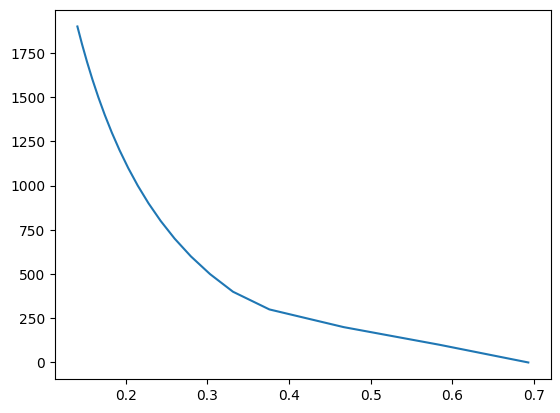

In [24]:
x=d['costs']
y=range(0,2000,100)
plt.plot(x,y)

# Evaluation metrics for Classification

Precision is defined as the number of true positives divided by the number of predicted positives.
$$Precision=\frac{TP}{TP+FP}$$

Recall is defined as the number of true positives divided by the total number of actual positives.
$$Recall=\frac{TP}{TP+FN}$$

F1 Score is the harmonic mean of precision and recall.
$$F1 = 2*\frac{Precision * Recall}{Precision + Recall}$$
F1 score punishes extreme values more. It is best used when false positives and false negatives are equally undesirable outcomes.

# **Graded question

#FIND PRECISION, RECALL, AND F1 SCORE FOR BOTH TRAIN TEST PREDICTION.


In [ ]:


from sklearn.metrics import precision_score, recall_score, f1_score


y_train_pred = d['Y_prediction_train']
y_test_pred = d['Y_prediction_test']


precision_train = precision_score(train_y.flatten(), y_train_pred.flatten())
recall_train = recall_score(train_y.flatten(), y_train_pred.flatten())
f1_train = f1_score(train_y.flatten(), y_train_pred.flatten())


precision_test = precision_score(test_y.flatten(), y_test_pred.flatten())
recall_test = recall_score(test_y.flatten(), y_test_pred.flatten())
f1_test = f1_score(test_y.flatten(), y_test_pred.flatten())


print(f"Train Precision: {precision_train:.4f}")
print(f"Train Recall: {recall_train:.4f}")
print(f"Train F1 Score: {f1_train:.4f}")

print(f"\nTest Precision: {precision_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")
print(f"Test F1 Score: {f1_test:.4f}")

Train Precision: 0.9861
Train Recall: 0.9861
Train F1 Score: 0.9861

Test Precision: 0.8214
Test Recall: 0.6970
Test F1 Score: 0.7541


In [ ]:
from numpy import pi

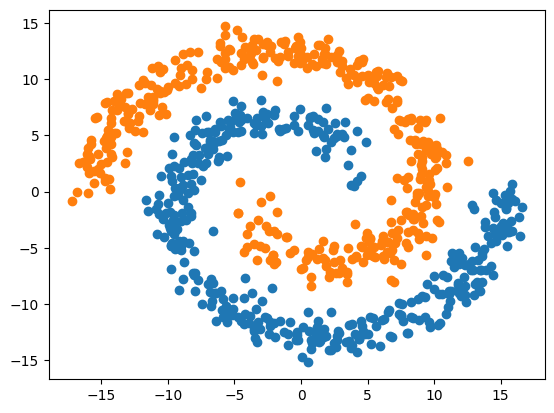

In [ ]:

N = 400
theta = np.sqrt(np.random.rand(N))*2*pi # np.linspace(0,2*pi,100)

r_a = 2*theta + pi
data_a = np.array([np.cos(theta)*r_a, np.sin(theta)*r_a]).T
x_a = data_a + np.random.randn(N,2)

r_b = -2*theta - pi
data_b = np.array([np.cos(theta)*r_b, np.sin(theta)*r_b]).T
x_b = data_b + np.random.randn(N,2)

res_a = np.append(x_a, np.zeros((N,1)), axis=1)
res_b = np.append(x_b, np.ones((N,1)), axis=1)

res = np.append(res_a, res_b, axis=0)
np.random.shuffle(res)

np.savetxt("result.csv", res, delimiter=",", header="x,y,label", comments="", fmt='%.5f')

plt.scatter(x_a[:,0],x_a[:,1])
plt.scatter(x_b[:,0],x_b[:,1])
plt.show()

In [ ]:
np.savetxt("result.csv", res, delimiter=",", header="x,y,label", comments="", fmt='%.5f')


In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
# Load the dataset
data = pd.read_csv("result.csv")

# Preview the first few rows
print(data.head())


          x        y  label
0  -3.86801 -3.05481    1.0
1  15.56839 -0.98336    0.0
2   4.82314  8.17743    1.0
3  15.14958 -3.46977    0.0
4  15.29320 -0.26641    0.0


In [ ]:
# Features (x and y)
X = data[['x', 'y']].values

# Labels (class 0 or 1)
y = data['label'].values


FIND PRECISION, RECALL, AND F1 SCORE FOR BOTH TRAIN TEST PREDICTION